In [1]:
from tensorflow.keras import layers, models, applications
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


# **1. Load the ResNet50 base without the top classification layer**
The ResNet50 was originally designed for the ImageNet dataset- by doing



include_top=False, we remove the 1000 classes classification layer, and use only the feature extraction part

weights = None: we are not using the pre-trained knowledge, but forcing the ResNet model to learn using only our Cifar10 dataset



In [4]:
# We use 'None' for weights if training from scratch, or 'imagenet' for pre-trained
base_model = applications.ResNet50(
    include_top=False,
    weights=None,
    input_shape=(32, 32, 3)
)

# 2. The Custom Classification Head

In [5]:
resnet_model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

In [6]:
custom_adam = tf.keras.optimizers.Adam(learning_rate=0.0001)

# Pass the object into the compile method
resnet_model.compile(
    optimizer=custom_adam,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1
)

training_set = train_datagen.flow(x_train, y_train, batch_size=64)

In [8]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_set = test_datagen.flow(x_test, y_test, batch_size=64)

In [9]:
# We flow the entire dataset (100%) through the generator
training_set_full = train_datagen.flow(x_train, y_train, batch_size=64)

print("--- Starting Full Dataset Training for ResNet50 ---")

# We train for the same number of epochs as the vanilla CNN for consistency
# --- 1. Shuffle Data for Random Subsets ---
np.random.seed(42)
indices = np.random.permutation(len(x_train))
x_train_shuffled = x_train[indices]
y_train_shuffled = y_train[indices]

# --- 2. Master History Tracker ---
progressive_history = {
    'accuracy': [], 'val_accuracy': [],
    'loss': [], 'val_loss': []
}

# --- 3. Progressive Training Loop ---
fractions = [0.10, 0.25, 0.50, 0.75, 1.00]
epochs_per_stage = 5  # Total of 25 epochs

for stage_idx, fraction in enumerate(fractions):
    n_samples = int(len(x_train_shuffled) * fraction)

    # Slice the subset
    x_subset = x_train_shuffled[:n_samples]
    y_subset = y_train_shuffled[:n_samples]

    # Create a fresh generator for this subset
    current_training_set = train_datagen.flow(x_subset, y_subset, batch_size=64)

    print(f"\n{'='*60}")
    print(f"STAGE {stage_idx + 1}: Training with {fraction*100:.0f}% data ({n_samples:,} samples)")
    print(f"{'='*60}")

    # Train (Model remembers weights from the previous loop iteration)
    stage_hist = resnet_model.fit(
        current_training_set,
        epochs=epochs_per_stage,
        validation_data=(x_test / 255.0, y_test), # Keep validation consistent
        verbose=1
    )

    # Append results to master history
    for key in progressive_history:
        progressive_history[key].extend(stage_hist.history[key])

print("\n--- Progressive Revelation Complete ---")

--- Starting Full Dataset Training for ResNet50 ---

STAGE 1: Training with 10% data (5,000 samples)
Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 90s 452ms/step - accuracy: 0.1114 - loss: 3.2888 - val_accuracy: 0.1002 - val_loss: 2.3244
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - accuracy: 0.1394 - loss: 2.9914 - val_accuracy: 0.1000 - val_loss: 2.4568
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - accuracy: 0.1478 - loss: 2.8675 - val_accuracy: 0.0983 - val_loss: 2.6616
Epoch 4/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step - accuracy: 0.1582 - loss: 2.6978 - val_accuracy: 0.1081 - val_loss: 2.8055
Epoch 5/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - accuracy: 0.1740 - loss: 2.5771 - val_accuracy: 0.1159 - val_loss: 2.7693

STAGE 2: Training with 25% data (12,500 samples)
Epoch 1/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 36s 185ms/step - accuracy: 0.1875 - loss: 2.4227 - val_accuracy: 0.2162 - val_loss: 2.1194
Epoch 2/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 13s 66ms/step - accuracy: 0.1976 - loss: 2.2885 

In [10]:
# 1. Evaluate on the Test Set
test_loss, test_acc = resnet_model.evaluate(test_set, verbose=1)

print(f"\n{'='*30}")
print(f"RESNET TEST RESULTS")
print(f"{'='*30}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss:     {test_loss:.4f}")

157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.5349 - loss: 1.3180

RESNET TEST RESULTS
Test Accuracy: 0.5349
Test Loss:     1.3180


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


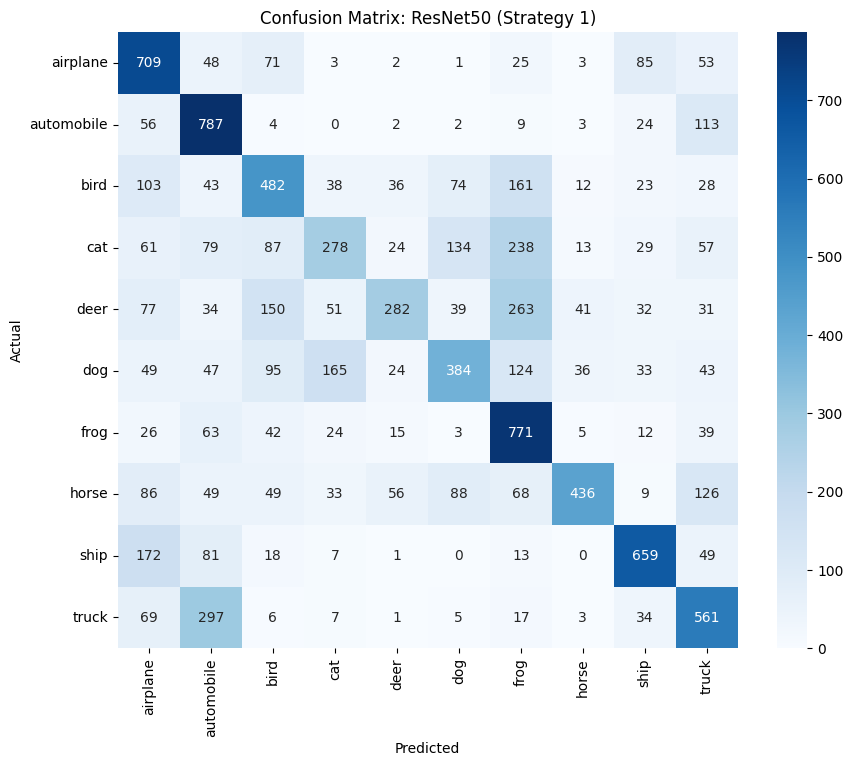

In [12]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Get all images and labels from the test set
# Note: We use the raw x_test (scaled) to ensure we get 1-to-1 mapping
x_test_scaled = x_test.astype('float32') / 255.0
y_pred_probs = resnet_model.predict(x_test_scaled)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

# Generate Matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix: ResNet50 (Strategy 1)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

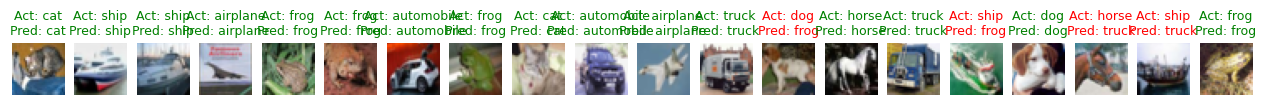

In [14]:
def plot_actual_vs_predicted(images, labels, predictions, class_names, n=20):
    plt.figure(figsize=(16, 4))
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(images[i])

        actual = class_names[labels[i]]
        pred = class_names[predictions[i]]
        color = 'green' if actual == pred else 'red'

        plt.title(f"Act: {actual}\nPred: {pred}", color=color, fontsize=9)
        plt.axis('off')
    plt.show()

# Visualize the first 8 images of the test set
plot_actual_vs_predicted(x_test, y_true, y_pred_classes, class_names)

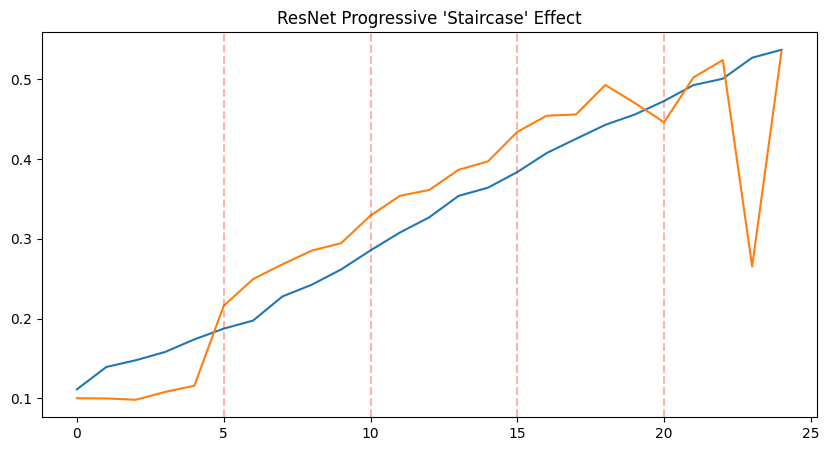

In [15]:
# Use this to see the "Staircase"
plt.figure(figsize=(10, 5))
plt.plot(progressive_history['accuracy'], label='Train')
plt.plot(progressive_history['val_accuracy'], label='Val')
for i in range(1, 5):
    plt.axvline(x=i*5, color='r', linestyle='--', alpha=0.3) # Marks the data jumps
plt.title("ResNet Progressive 'Staircase' Effect")
plt.show()